# Notebook 7: Scenario Analysis

Every model built in this module rests on at least one assumption that was stated rather than measured: an
assumed adjuster capacity, an assumed percent paid on a brand-new catastrophe, a chosen recall target for
the fraud model. A number that only holds under one specific assumption is not something a leadership team
can safely act on. This notebook re-runs three earlier results across a plausible range of their key
assumptions, to see how much the conclusion actually depends on the exact number chosen.

Three what-if questions are worked through, each connecting back to an earlier notebook:
1. How sensitive is the Hurricane Marisol reserve estimate to the assumed percent paid so far? (Notebook 5)
2. How much does adjuster staffing level change claims triage outcomes? (Notebook 6)
3. How does the fraud model's recall target trade off against precision? (Notebook 4)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 20)

TODAY = pd.Timestamp("2026-08-17")
DATA_DIR = "../04_Datasets/"

print("Setup complete.")

Setup complete.


## 1. Reserve Estimate Sensitivity: What If the Percent-Paid Assumption Is Wrong?

Notebook 5's Bornhuetter-Ferguson estimate for Hurricane Marisol used a stated assumption of 5% paid so far,
justified as a judgment call rather than something measured from Gulf Crest's own thin data. Since that
number was a judgment call, not a measurement, it is worth asking directly how much the final reserve
figure would move if that judgment turns out to be off.

In [2]:
claims = pd.read_csv(DATA_DIR + "02_claims.csv")

prior_expected_ultimate = claims.loc[claims["is_catastrophe_flag"] == "Y", "reported_severity"].sum()
paid_so_far = 38_371.64  # carried over from Notebook 5

percent_paid_scenarios = [0.02, 0.03, 0.05, 0.08, 0.10, 0.15]
reserve_sensitivity = pd.DataFrame({
    "Assumed Percent Paid So Far": [f"{p:.0%}" for p in percent_paid_scenarios],
    "BF Ultimate Estimate": [
        paid_so_far + prior_expected_ultimate * (1 - p) for p in percent_paid_scenarios
    ],
})
reserve_sensitivity["Reserve Needed"] = reserve_sensitivity["BF Ultimate Estimate"] - paid_so_far
reserve_sensitivity[["BF Ultimate Estimate", "Reserve Needed"]] = reserve_sensitivity[
    ["BF Ultimate Estimate", "Reserve Needed"]
].round(0)
reserve_sensitivity

,Assumed Percent Paid So Far,BF Ultimate Estimate,Reserve Needed
0,2%,164677628.0,164639257.0
1,3%,162997636.0,162959264.0
2,5%,159637651.0,159599280.0
3,8%,154597674.0,154559302.0
4,10%,151237689.0,151199318.0
5,15%,142837727.0,142799355.0


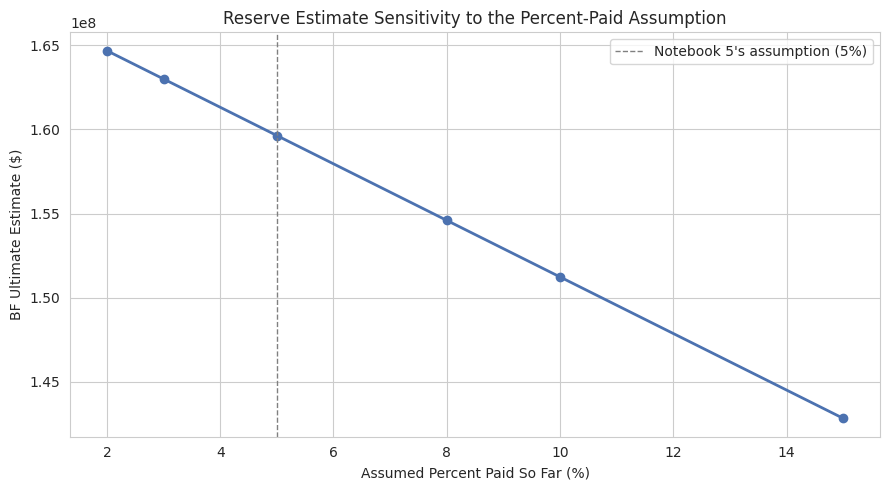

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot([p*100 for p in percent_paid_scenarios], reserve_sensitivity["BF Ultimate Estimate"],
        marker="o", color="#4C72B0", linewidth=2)
ax.set_xlabel("Assumed Percent Paid So Far (%)")
ax.set_ylabel("BF Ultimate Estimate ($)")
ax.set_title("Reserve Estimate Sensitivity to the Percent-Paid Assumption")
ax.axvline(5, color="gray", linestyle="--", linewidth=1, label="Notebook 5's assumption (5%)")
ax.legend()
plt.tight_layout()
plt.savefig("outputs_reserve_sensitivity.png", dpi=120)
plt.show()

The ultimate estimate moves by about $22 million across a fairly wide range of the assumption (2% to
15% paid so far), against a base case near $160 million. That is a real amount of money, but it is a
modest swing (roughly plus or minus 7%) relative to how much the underlying assumption itself moved (a
factor of more than seven, from 2% to 15%). The reserve estimate is far more sensitive to the prior expected
ultimate (the adjusters' bottom-up total) than to the percent-paid assumption, which is a reassuring
property of Bornhuetter-Ferguson: it is built specifically to not swing wildly on the thinnest, least
reliable part of the input.

## 2. Claims Triage Sensitivity: What If Adjuster Capacity Changes?

Notebook 6 assumed Gulf Crest could close 100 claims per day. Staffing is one of the more direct levers
Gulf Crest's management actually controls, whether through overtime, temporary contractors after a
catastrophe, or reduced staffing during a slow season, so it is worth seeing how much that single number
changes the outcome.

In [4]:
claims["date_reported"] = pd.to_datetime(claims["date_reported"])
open_claims = claims[claims["claim_status"] == "Open"].copy()
open_claims["days_open"] = (TODAY - open_claims["date_reported"]).dt.days

def minmax_scale(series):
    return (series - series.min()) / (series.max() - series.min())

open_claims["severity_score"] = minmax_scale(open_claims["reported_severity"])
open_claims["age_score"] = minmax_scale(open_claims["days_open"])
open_claims["catastrophe_score"] = (open_claims["is_catastrophe_flag"] == "Y").astype(float)
open_claims["priority_score"] = (
    0.5 * open_claims["severity_score"] + 0.3 * open_claims["age_score"] + 0.2 * open_claims["catastrophe_score"]
)

capacity_scenarios = [50, 75, 100, 125, 150]
capacity_results = []
for capacity in capacity_scenarios:
    queue = open_claims.sort_values("priority_score", ascending=False).reset_index(drop=True)
    queue["days_to_close"] = (np.arange(len(queue)) // capacity) + 1
    capacity_results.append({
        "Adjuster Capacity (claims/day)": capacity,
        "Days to Clear Backlog": queue["days_to_close"].max(),
        "Dollar-Weighted Avg Days to Close": round(
            np.average(queue["days_to_close"], weights=queue["reported_severity"]), 2
        ),
    })

capacity_sensitivity = pd.DataFrame(capacity_results)
capacity_sensitivity

,Adjuster Capacity (claims/day),Days to Clear Backlog,Dollar-Weighted Avg Days to Close
0,50,41,8.10
1,75,28,5.60
2,100,21,4.35
3,125,17,3.60
4,150,14,3.11


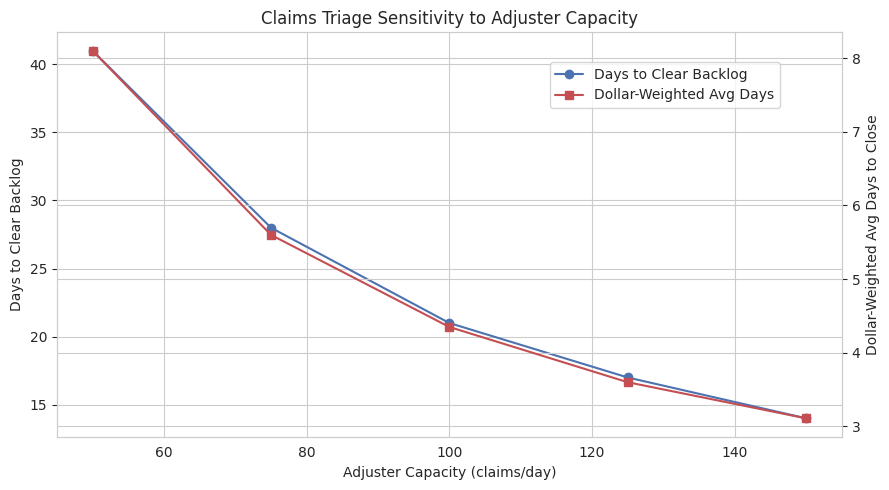

In [5]:
fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()
ax1.plot(capacity_sensitivity["Adjuster Capacity (claims/day)"], capacity_sensitivity["Days to Clear Backlog"],
          marker="o", color="#4C72B0", label="Days to Clear Backlog")
ax2.plot(capacity_sensitivity["Adjuster Capacity (claims/day)"], capacity_sensitivity["Dollar-Weighted Avg Days to Close"],
          marker="s", color="#C44E52", label="Dollar-Weighted Avg Days")
ax1.set_xlabel("Adjuster Capacity (claims/day)")
ax1.set_ylabel("Days to Clear Backlog")
ax2.set_ylabel("Dollar-Weighted Avg Days to Close")
ax1.set_title("Claims Triage Sensitivity to Adjuster Capacity")
fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.savefig("outputs_capacity_sensitivity.png", dpi=120)
plt.show()

The relationship is smooth rather than showing a sharp breakpoint: doubling capacity from 75 to 150
claims per day roughly halves both the time to clear the backlog and the dollar-weighted average wait. There
is no sign of an obvious bottleneck at any capacity level tested here. That means a staffing decision can be
made on cost grounds (what does an extra adjuster, or a week of overtime, cost against what it buys in
faster claim resolution) without also worrying about hitting some hidden inflection point in the queue's
behavior.

## 3. Fraud Detection Sensitivity: What Does a Higher Recall Target Cost?

Notebook 4 targeted at least 80% recall for the fraud classifier and accepted a real cost in precision to
get there. That target itself was a choice, not a fixed requirement, so the next natural question is how the
trade-off looks at other targets: is 80% close to a reasonable balance point, or was it an arbitrary
stopping point along a curve that keeps getting better, or worse, elsewhere?

In [6]:
policies = pd.read_csv(DATA_DIR + "01_policies.csv")
fraud_labels = pd.read_csv(DATA_DIR + "06_fraud_labels.csv")
repair_costs = pd.read_csv(DATA_DIR + "05_repair_costs.csv")

data = claims.merge(policies, on="policy_id").merge(fraud_labels, on="claim_id", how="left")
data["date_of_loss"] = pd.to_datetime(data["date_of_loss"])
data["days_to_report"] = (data["date_reported"] - data["date_of_loss"]).dt.days
data["property_age_at_loss"] = data["date_of_loss"].dt.year - data["year_built"]

repair_summary = repair_costs.groupby("claim_id").agg(
    repair_line_items=("repair_category", "count"),
    estimated_total=("estimated_cost", "sum"),
    actual_total=("actual_cost", "sum"),
).reset_index()
repair_summary["cost_overrun_ratio"] = (
    (repair_summary["actual_total"] - repair_summary["estimated_total"]) / repair_summary["estimated_total"]
)
repair_summary["cost_overrun_known"] = repair_summary["cost_overrun_ratio"].notna().astype(int)
repair_summary["cost_overrun_ratio"] = repair_summary["cost_overrun_ratio"].fillna(0.0)
data = data.merge(
    repair_summary[["claim_id", "repair_line_items", "cost_overrun_ratio", "cost_overrun_known"]],
    on="claim_id", how="left"
)
data["repair_line_items"] = data["repair_line_items"].fillna(0)
data["cost_overrun_ratio"] = data["cost_overrun_ratio"].fillna(0.0)
data["cost_overrun_known"] = data["cost_overrun_known"].fillna(0).astype(int)
data["severity_to_tiv_ratio"] = data["reported_severity"] / data["total_insured_value"]

labeled = data.dropna(subset=["is_fraud"]).copy()
labeled["is_fraud"] = labeled["is_fraud"].astype(int)

numeric_features = [
    "total_insured_value", "reported_severity", "days_to_report", "property_age_at_loss",
    "severity_to_tiv_ratio", "repair_line_items", "cost_overrun_ratio",
]
categorical_features = [
    "coastal_zone_flag", "construction_type", "coverage_type", "cause_of_loss",
    "is_catastrophe_flag", "cost_overrun_known",
]
X = labeled[numeric_features + categorical_features]
y = labeled["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
X_fit, X_val, y_fit, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42, stratify=y_train)

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ("num", StandardScaler(), numeric_features),
])
X_fit_encoded = preprocessor.fit_transform(X_fit)
X_val_encoded = preprocessor.transform(X_val)
X_test_encoded = preprocessor.transform(X_test)

X_fit_resampled, y_fit_resampled = SMOTE(random_state=42).fit_resample(X_fit_encoded, y_fit)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_fit_resampled, y_fit_resampled)

val_probs = model.predict_proba(X_val_encoded)[:, 1]
test_probs = model.predict_proba(X_test_encoded)[:, 1]
precisions, recalls, curve_thresholds = precision_recall_curve(y_val, val_probs)

recall_targets = [0.50, 0.60, 0.70, 0.80, 0.90]
recall_sensitivity = []
for target in recall_targets:
    candidates = [i for i in range(len(curve_thresholds)) if recalls[i] >= target]
    if not candidates:
        continue
    best_index = max(candidates, key=lambda i: precisions[i])
    threshold = curve_thresholds[best_index]
    preds = (test_probs >= threshold).astype(int)
    recall_sensitivity.append({
        "Recall Target": f"{target:.0%}",
        "Threshold": round(threshold, 3),
        "Actual Precision": round(precision_score(y_test, preds, zero_division=0), 3),
        "Actual Recall": round(recall_score(y_test, preds, zero_division=0), 3),
        "F1": round(f1_score(y_test, preds, zero_division=0), 3),
    })

recall_sensitivity_df = pd.DataFrame(recall_sensitivity)
recall_sensitivity_df

,Recall Target,Threshold,Actual Precision,Actual Recall,F1
0,50%,0.524,0.174,0.532,0.262
1,60%,0.467,0.171,0.677,0.273
2,70%,0.407,0.178,0.855,0.294
3,80%,0.359,0.174,0.903,0.292
4,90%,0.204,0.151,0.968,0.261


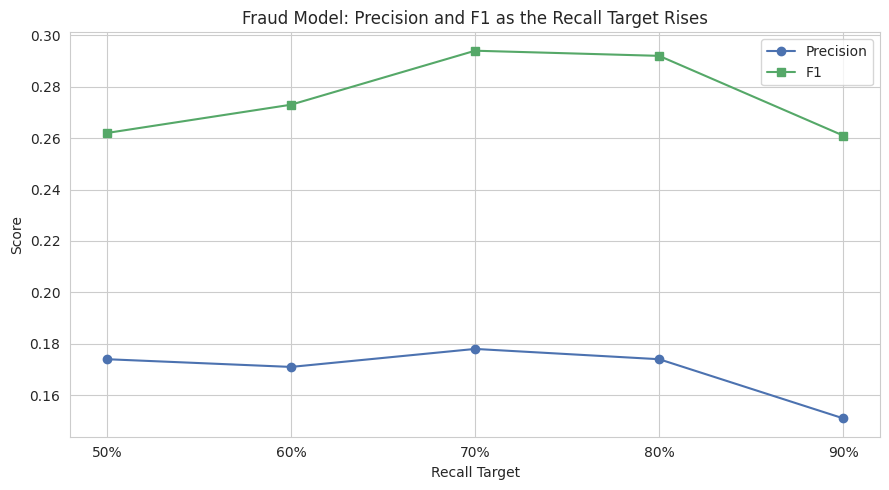

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(recall_sensitivity_df["Recall Target"], recall_sensitivity_df["Actual Precision"],
        marker="o", label="Precision", color="#4C72B0")
ax.plot(recall_sensitivity_df["Recall Target"], recall_sensitivity_df["F1"],
        marker="s", label="F1", color="#55A868")
ax.set_xlabel("Recall Target")
ax.set_ylabel("Score")
ax.set_title("Fraud Model: Precision and F1 as the Recall Target Rises")
ax.legend()
plt.tight_layout()
plt.savefig("outputs_fraud_recall_sensitivity.png", dpi=120)
plt.show()

F1 peaks around a 70% recall target and declines on both sides of it, gently below 70% and more sharply
above 80%, as precision keeps eroding to buy each additional point of recall. Notebook 4's 80% target sits
just past that peak: a deliberate choice to prioritize catching fraud over overall balance, consistent with
treating a missed fraud case as more costly than an extra false alarm, but the sensitivity curve shows that
choice explicitly rather than leaving it implied. Pushing the target to 90% would cost noticeably more
precision for comparatively little additional recall, a point of diminishing returns Gulf Crest's SIU should
weigh against its actual investigation capacity.

## Summary

1. The Hurricane Marisol reserve estimate is fairly stable to the assumed percent-paid figure: a wide range
   of plausible assumptions (2% to 15%) moves the ultimate estimate by about 7% in either direction, far
   less than the assumption itself moved. Bornhuetter-Ferguson is doing what it is designed to do here,
   staying anchored to the more reliable prior rather than swinging on the thinnest part of the data.
2. Claims triage outcomes scale smoothly with adjuster capacity, with no hidden breakpoint in the range
   tested. A staffing decision can reasonably be made on cost grounds alone.
3. The fraud model's precision-recall trade-off peaks in F1 terms around a 70% recall target. The 80% target
   used in Notebook 4 was a deliberate, explainable choice to favor catching fraud over overall balance, not
   an arbitrary stopping point, and the cost of pushing further (to 90%) is now visible and can be weighed
   directly against SIU capacity.
4. Across all three, none of the earlier notebooks' conclusions turn out to hinge on a single fragile
   number. That is itself a meaningful finding worth reporting to Gulf Crest's leadership, and it is exactly
   what a scenario analysis is meant to check for before a model's output gets used to make a real decision.

**Next:** Open `08_Final_Recommendation.ipynb` for a written summary tying every notebook's findings
together into a set of recommendations for Gulf Crest's leadership.